# **Predicting Electric Vehicle Purchases**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# preprocess
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# model 
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import accuracy_score, roc_curve, classification_report, confusion_matrix

# Hyperparameter Tuning
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

In [3]:
train_data = pd.read_csv(r"D:\Downloads\1. DESKTOP\Projects\1. ML project\Predicting Electric Vehicle Purchases\Data\train.csv")
test_data = pd.read_csv(r"D:\Downloads\1. DESKTOP\Projects\1. ML project\Predicting Electric Vehicle Purchases\Data\test.csv")
train_data.shape, test_data.shape

((668665, 15), (286571, 14))

In [5]:
# train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
# test_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")
# train_data.shape, test_data.shape

### Data Prepare and Understand

In [6]:
train_data.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [7]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [8]:
# Check NULL
train_data.isnull().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

In [9]:
# Check DUPLICATES
train_data.duplicated().sum()

0

### Encoding

In [10]:
train_data.head(2)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No


In [11]:
train_data.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='str')

In [12]:
encode_col = ['Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level']

for col in encode_col:
    print(f"{col}:-  {train_data[col].unique()}")


Gender:-  <ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
City_Type:-  <ArrowStringArray>
['Suburban', 'Rural', 'Urban']
Length: 3, dtype: str
Current_Car_Type:-  <ArrowStringArray>
['Sedan', 'SUV', 'Hatchback', 'Truck']
Length: 4, dtype: str
Home_Charging_Possible:-  <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Subsidy_Available:-  <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Range_Anxiety_Level:-  <ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str


In [13]:
def Encoder_Func(data):

    mappings = {
        "City_Type": {
            "Suburban": 0,
            "Rural": 1,
            "Urban": 2
        },

        "Current_Car_Type": {
            "Sedan": 0,
            "SUV": 1,
            "Hatchback": 2,
            "Truck": 3
        },

        "Range_Anxiety_Level": {
            "Low": 0,
            "Medium": 1,
            "High": 2
        },

        "Gender": {
            "Male": 0,
            "Female": 1,
            "Other": 2
        },

        "Home_Charging_Possible": {
            "Yes": 1,
            "No": 0
        },

        "Subsidy_Available": {
            "Yes": 1,
            "No": 0
        }

    }

    for col, mapping in mappings.items():
        data[col] = data[col].map(mapping)

    return data

train_data["Will_Buy_EV"] = train_data['Will_Buy_EV'].map({"No": 0, "Yes": 1})
train_data = Encoder_Func(train_data)
train_data.head(2)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,0,0,0,1,0,0,0
1,1,38,30000.0,5.0,1,2,2,4.0,0,1,1,1,0,0,0


## Data Visualization

#### Class Counting

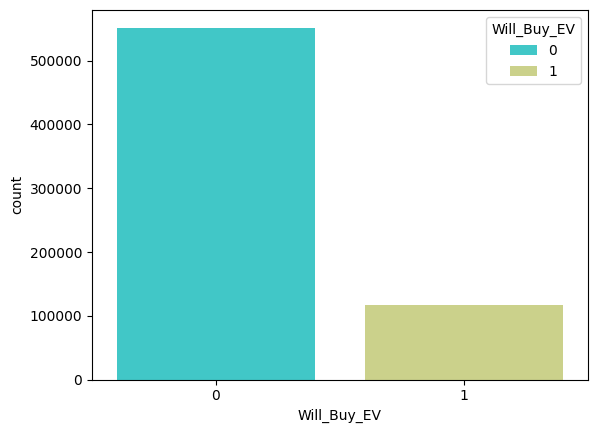

In [11]:
sns.countplot(data=train_data, x="Will_Buy_EV", hue="Will_Buy_EV", palette="rainbow", legend=True)
plt.show()

#### Column Corelation Check

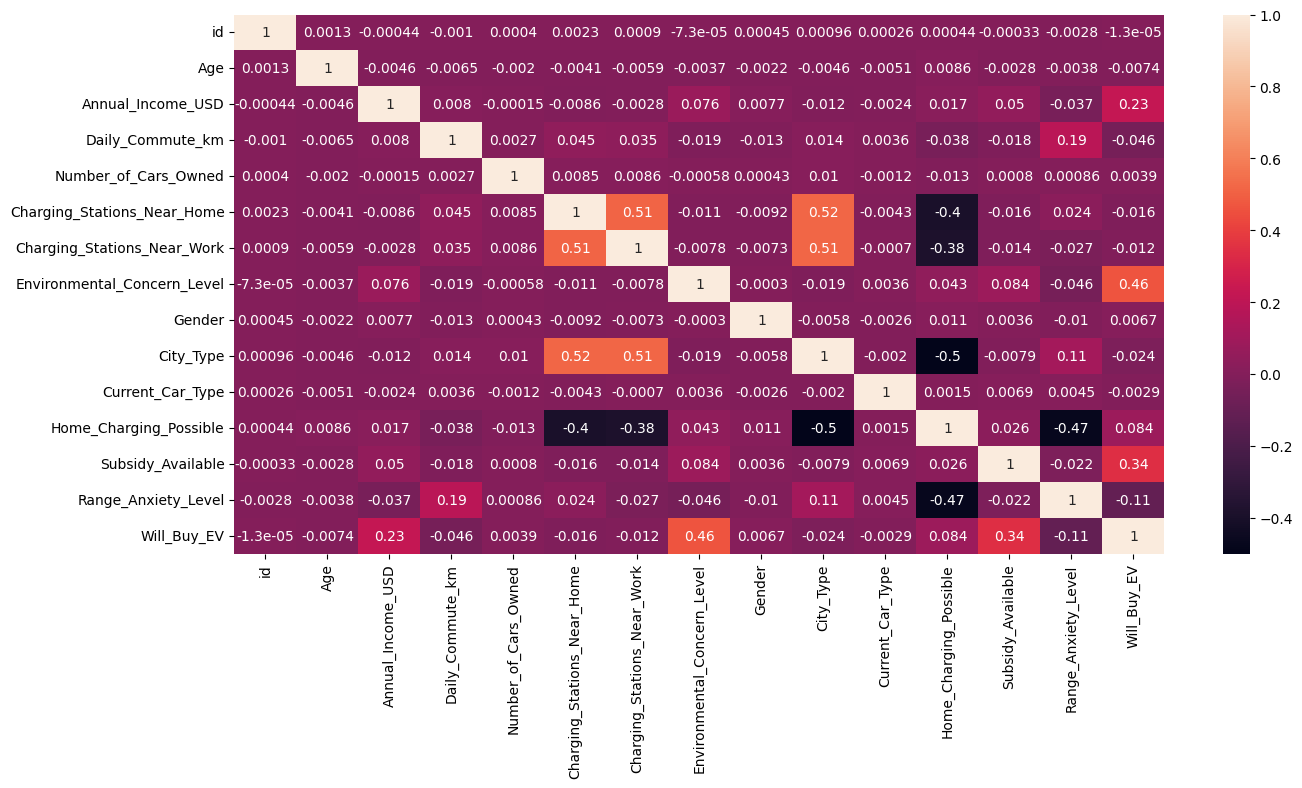

In [12]:
plt.figure(figsize=(15, 7))
sns.heatmap(data=train_data.corr(), annot=True)
plt.show() 

### Car Buy Age Category

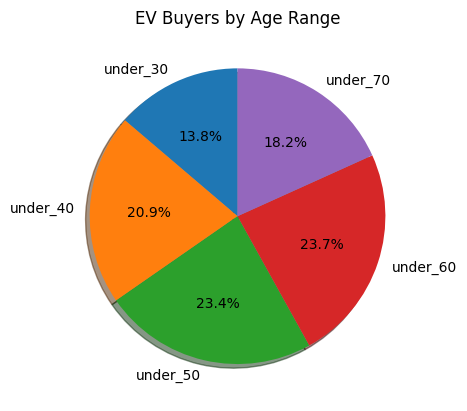

In [13]:
age_under_30 = len(train_data[(train_data['Age'] > 20) & (train_data['Age'] <=  30) & (train_data["Will_Buy_EV"] == 1)])
age_under_40 = len(train_data[(train_data['Age'] > 30) & (train_data['Age'] <= 40) & (train_data["Will_Buy_EV"] == 1)])
age_under_50 = len(train_data[(train_data['Age'] > 40) & (train_data['Age'] <= 50) & (train_data["Will_Buy_EV"] == 1)])
age_under_60 = len(train_data[(train_data['Age'] > 50) & (train_data['Age'] <= 60) & (train_data["Will_Buy_EV"] == 1)])
age_under_70 = len(train_data[(train_data['Age'] > 60) & (train_data['Age'] <= 70) & (train_data["Will_Buy_EV"] == 1)])

buy_age_category = [age_under_30, age_under_40, age_under_50, age_under_60, age_under_70]
labels = ["under_30", "under_40", "under_50", "under_60", "under_70"]

plt.pie(
    buy_age_category, 
    labels=labels, 
    autopct='%1.1f%%', 
    shadow=True,      
    startangle=90 
)

plt.title("EV Buyers by Age Range")
plt.show()

### EV Buyers by Salary Range

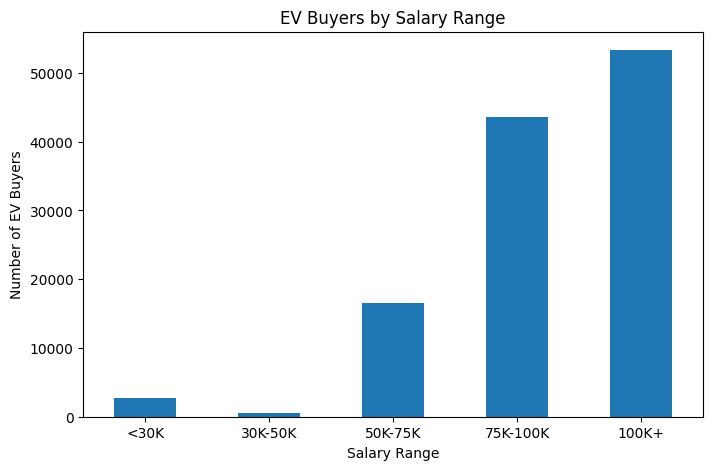

In [14]:
bins = [0, 30000, 50000, 75000, 100000, float("inf")]
labels = ["<30K", "30K-50K", "50K-75K", "75K-100K", "100K+"]

train_data["Salary_Range"] = pd.cut(
    train_data["Annual_Income_USD"],
    bins=bins,
    labels=labels
)

# Har salary range mein EV buyers
buyers = (
    train_data[train_data["Will_Buy_EV"] == 1]
    .groupby("Salary_Range", observed=False)
    .size()
)

buyers.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Salary Range")
plt.ylabel("Number of EV Buyers")
plt.title("EV Buyers by Salary Range")
plt.xticks(rotation=0)
plt.show()

### Data Scaling

In [15]:
train_data.drop("Salary_Range", axis=1, inplace=True)
train_data.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,0,0,0,1,0,0,0
1,1,38,30000.0,5.0,1,2,2,4.0,0,1,1,1,0,0,0
2,2,26,94389.0,36.8,1,8,15,5.0,1,2,0,0,1,0,1
3,3,66,73580.0,23.7,2,6,9,3.0,0,0,2,1,0,0,0
4,4,54,57898.0,50.8,1,2,3,3.0,0,0,2,1,0,0,0


In [14]:
x = train_data.drop("Will_Buy_EV", axis=1)
y = train_data['Will_Buy_EV'].values

In [15]:
ss = StandardScaler()
ss.fit(x)

StandardScaler()

In [16]:
x = ss.transform(x)
x

array([[-1.73204822,  1.47263561,  0.28336117, ...,  0.66723989,
        -1.29924427, -0.32186527],
       [-1.73204304, -0.70204758, -1.91180021, ...,  0.66723989,
        -1.29924427, -0.32186527],
       [-1.73203786, -1.63405467,  0.33579065, ..., -1.49871135,
         0.76967821, -0.32186527],
       ...,
       [ 1.73203786,  1.3173011 ,  1.29229695, ...,  0.66723989,
         0.76967821, -0.32186527],
       [ 1.73204304,  0.30762676,  1.08746596, ...,  0.66723989,
         0.76967821, -0.32186527],
       [ 1.73204822,  0.54062853, -0.55093768, ..., -1.49871135,
         0.76967821, -0.32186527]])

In [17]:
y 

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

### **Data Emblanced handling**

In [18]:
train_data['Will_Buy_EV'].value_counts()

Will_Buy_EV
0    551886
1    116779
Name: count, dtype: int64

In [19]:
# # UnderSampling
# und_sam = RandomUnderSampler(random_state=42)
# und_x, und_y = und_sam.fit_resample(x, y)

In [20]:
# OverSampling
ovr_sam = RandomOverSampler(random_state=42)
ovr_x, ovr_y = ovr_sam.fit_resample(x, y)

### Data Spliting

In [21]:
x_train, x_test, y_train, y_test = train_test_split(
        ovr_x, ovr_y,
        test_size=0.1,
        random_state=42
)

## Build Model

#### Logistic Regression

In [24]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

lr.score(x_test, y_test), lr.score(x_train, y_train)

(0.8706263929406223, 0.8723980615948959)

#### SVM

In [25]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

gnb.score(x_test, y_test), gnb.score(x_train, y_train)

(0.8534128177716575, 0.8533411717807838)

#### Decision Tree

In [26]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

dt.score(x_test, y_test), dt.score(x_train, y_train)

(0.9522640381235391, 1.0)

#### RandomForest

In [22]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

rf.score(x_test, y_test), rf.score(x_train, y_train)

(0.957509648661871, 0.9999989933500706)

#### Xgboost

In [28]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)

xgb.score(x_test, y_test), xgb.score(x_train, y_train)

(0.8813169290981898, 0.8839342697862077)

#### Catboost

In [23]:
# ctb = CatBoostClassifier()
# ctb.fit(x_train, y_train)

# ctb.score(x_test, y_test), ctb.score(x_train, y_train)

#### LGBM

In [30]:
lgbm = LGBMClassifier()
lgbm.fit(x_train, y_train)

lgbm.score(x_test, y_test), lgbm.score(x_train, y_train)

[LightGBM] [Info] Number of positive: 496529, number of negative: 496865
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.070055 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 882
[LightGBM] [Info] Number of data points in the train set: 993394, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499831 -> initscore=-0.000676
[LightGBM] [Info] Start training from score -0.000676


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(0.8773396872565186, 0.8778973901593929)

### **Final Model Train**

In [24]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

rf.score(x_test, y_test), rf.score(x_train, y_train)

(0.9571381978292776, 0.9999989933500706)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


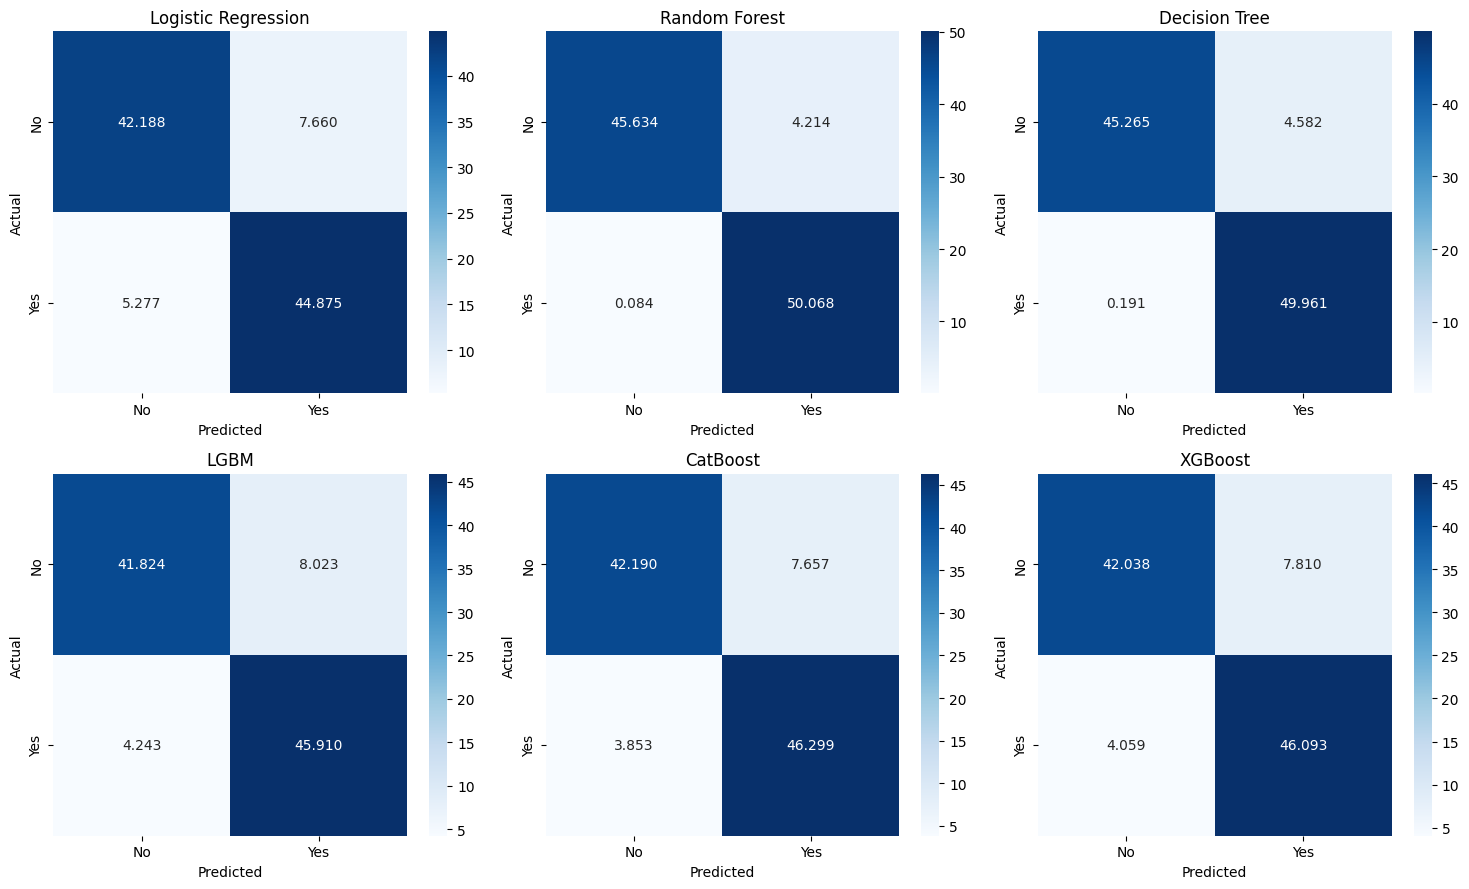

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": lr.predict(x_test),
    "Random Forest": rf.predict(x_test),
    "Decision Tree": dt.predict(x_test),
    "LGBM": lgbm.predict(x_test),
    "CatBoost": ctb.predict(x_test),
    "XGBoost": xgb.predict(x_test)
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (name, y_pred) in zip(axes, models.items()):

    cm = (confusion_matrix(y_test, y_pred) / len(y_test))*100

    sns.heatmap(
        cm,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        ax=ax,
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

# annotations mein % add karna ho to custom formatting kar sakte ho

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### **Evaluation**

In [24]:
y_prd = rf.predict(x_test)

print("1. Accuracy:", accuracy_score(y_test, y_prd)*100)

print()
print("2. Classification Report:")
print(classification_report(y_test, y_prd))

1. Accuracy: 95.7509648661871

2. Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     55021
           1       0.92      1.00      0.96     55357

    accuracy                           0.96    110378
   macro avg       0.96      0.96      0.96    110378
weighted avg       0.96      0.96      0.96    110378



Text(0.5, 23.52222222222222, 'Actual')

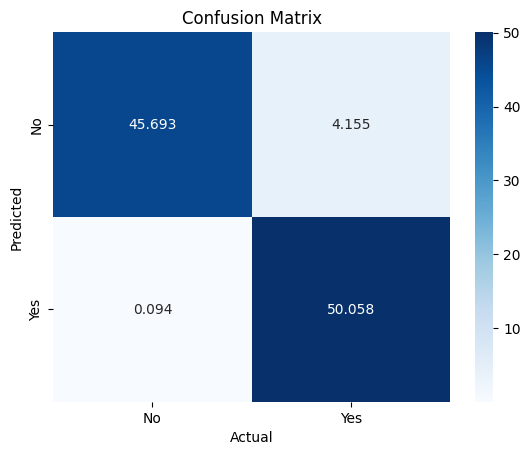

In [25]:
cm = (confusion_matrix(y_test, y_prd) / len(y_test))*100

sns.heatmap(
    cm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

# annotations mein % add karna ho to custom formatting kar sakte ho

plt.title("Confusion Matrix")
plt.ylabel("Predicted")
plt.xlabel("Actual")

### Model and Scaler Save

In [26]:
joblib.dump(ss, "scaler.joblib")
print("Scaler SAVE")

Scaler SAVE


In [27]:
joblib.dump(rf, "model.joblib")
print("Model SAVE") 

Model SAVE


### **Kaggle Submission**

In [33]:
test_data.head() 

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


In [34]:
id = test_data['id']

x_data = Encoder_Func(test_data)
x_data = ss.transform(x_data)

final_prd = rf.predict_proba(x_data)[:, 1]

In [35]:
print(id.shape)
print(final_prd.shape)

(286571,)
(286571,)


In [36]:
submission = pd.DataFrame(data={"id": id, "Will_Buy_EV": final_prd})
submission.to_csv("submission_rf_ovr.csv", index=False)